In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
pd.set_option('display.max_columns', None)
plt.rcParams['figure.figsize'] = (10, 5)

## **1. Load data**

In [2]:
df = pd.read_csv(r'..\data\csv\train.csv', index_col=0, parse_dates=['timestamp'])
df_test = pd.read_csv(r'..\data\csv\test.csv', index_col=0, parse_dates=['timestamp'])
print('Shape:', df.shape)
print('Test Shape:', df_test.shape)
df.head()

Shape: (666085, 22)
Test Shape: (166413, 22)


,transaction_id,account_id,hour_of_day,day_of_week,is_weekend,amount,merchant_category,mcc_code,merchant_country,card_present,device_type,device_known,ip_risk_score,is_foreign_txn,time_since_last_s,velocity_1h,amount_vs_avg_ratio,account_age_days,has_2fa,credit_limit,is_fraud,fraud_pattern
timestamp,,,,,,,,,,,,,,,,,,,,,,
2022-01-01 00:00:01,TXN000277317,ACC0045807,0,5,1,65.78,utilities,4900,US,0,mobile_app,1,21.4,0,232,1,0.5266,1773,1,3849.06,0,NaN
2022-01-01 00:02:54,TXN000667824,ACC0028794,0,5,1,64.01,grocery,5411,DE,0,mobile_app,1,40.6,1,15,1,3.4563,2408,0,1742.87,0,NaN
2022-01-01 00:03:29,TXN000766996,ACC0005585,0,5,1,801.70,travel,4511,DE,0,mobile_app,0,24.2,1,36,0,11.4923,1692,1,5923.23,0,NaN
2022-01-01 00:05:39,TXN000525597,ACC0000492,0,5,1,352.71,hotel,7011,CA,1,pos_terminal,1,34.0,1,462,0,3.8205,3171,0,3544.65,0,NaN
2022-01-01 00:06:10,TXN000089982,ACC0033651,0,5,1,43.13,grocery,5411,US,0,mobile_app,1,45.4,0,184,1,0.7770,1255,0,2517.79,0,NaN


In [3]:
print('Timeline for train data: {} to {}'.format(df.index[0], df.index[-1]))
print('Timeline for test data: {} to {}'.format(df_test.index[0], df_test.index[-1]))


Timeline for train data: 2022-01-01 00:00:01 to 2023-12-31 23:59:42
Timeline for test data: 2024-01-01 00:01:02 to 2024-06-30 23:59:53


## **2. Structure Check**

In [4]:
df.info()
df.describe(include='all').T

<class 'pandas.DataFrame'>
DatetimeIndex: 666085 entries, 2022-01-01 00:00:01 to 2023-12-31 23:59:42
Data columns (total 22 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   transaction_id       666085 non-null  str    
 1   account_id           666085 non-null  str    
 2   hour_of_day          666085 non-null  int64  
 3   day_of_week          666085 non-null  int64  
 4   is_weekend           666085 non-null  int64  
 5   amount               666085 non-null  float64
 6   merchant_category    666085 non-null  str    
 7   mcc_code             666085 non-null  int64  
 8   merchant_country     666085 non-null  str    
 9   card_present         666085 non-null  int64  
 10  device_type          666085 non-null  str    
 11  device_known         666085 non-null  int64  
 12  ip_risk_score        666085 non-null  float64
 13  is_foreign_txn       666085 non-null  int64  
 14  time_since_last_s    666085 non-null  int64  

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
transaction_id,666085,666085,TXN000277317,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
account_id,666085,49633,ACC0009278,119,NaN,NaN,NaN,NaN,NaN,NaN,NaN
hour_of_day,666085.0,NaN,NaN,NaN,11.492873,6.919652,0.0,5.0,11.0,17.0,23.0
day_of_week,666085.0,NaN,NaN,NaN,3.006202,2.001676,0.0,1.0,3.0,5.0,6.0
is_weekend,666085.0,NaN,NaN,NaN,0.28728,0.452494,0.0,0.0,0.0,1.0,1.0
amount,666085.0,NaN,NaN,NaN,183.784785,317.298719,1.94,43.45,81.05,189.61,23833.77
merchant_category,666085,14,grocery,120252,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mcc_code,666085.0,NaN,NaN,NaN,5704.221295,549.142853,4511.0,5411.0,5734.0,5999.0,7995.0
merchant_country,666085,11,US,470367,NaN,NaN,NaN,NaN,NaN,NaN,NaN
card_present,666085.0,NaN,NaN,NaN,0.351177,0.477339,0.0,0.0,0.0,1.0,1.0


## **3. Data Cleaning Check**

### **3.1. Missing values**

In [5]:
missing = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
missing[missing > 0]

fraud_pattern    98.285804
dtype: float64

In [6]:
missing_test = (df_test.isnull().sum() / len(df_test) * 100).sort_values(ascending=False)
missing_test[missing_test > 0]

fraud_pattern    98.25855
dtype: float64

Only `fraud_pattern` has null values since non-fraud transactions wouldnot have fraud pattern.

### **3.2 Duplicate check**

In [7]:
print('Duplicate rows:', df.duplicated().sum())
print('Duplicate transaction_id:', df['transaction_id'].duplicated().sum())

Duplicate rows: 0
Duplicate transaction_id: 0


In [8]:
print('Duplicate rows in test data:', df_test.duplicated().sum())
print('Duplicate transaction_id in test data:', df_test['transaction_id'].duplicated().sum())

Duplicate rows in test data: 0
Duplicate transaction_id in test data: 0


There are not **null values** in dataset.
Overview, data is cleaned.

### **3.3 Datatype optimization**

In [9]:

binary_cols = ['is_weekend', 'card_present', 'is_foreign_txn',
               'device_known', 'has_2fa', 'is_fraud']

# Convert binary columns to int8 to save memory
for col in binary_cols:
    df[col] = df[col].astype('int8')
    df_test[col] = df_test[col].astype('int8')

## **4. Target Analysis**

In [10]:
print('Train data')
fraud_rate = df['is_fraud'].mean() * 100
print(f'Fraud rate: {fraud_rate:.2f}%')
print(df['is_fraud'].value_counts(normalize=True) * 100)
print(df[df['is_fraud']==1]['fraud_pattern'].value_counts(dropna=False))
print('-'*50)
print('Test data')
fraud_rate_test = df_test['is_fraud'].mean() * 100
print(f'Fraud rate: {fraud_rate_test:.2f}%')
print(df_test['is_fraud'].value_counts(normalize=True) * 100)
print(df_test[df_test['is_fraud']==1]['fraud_pattern'].value_counts(dropna=False))  

Train data
Fraud rate: 1.71%
is_fraud
0    98.285804
1     1.714196
Name: proportion, dtype: float64
fraud_pattern
card_not_present       4050
account_takeover       2228
card_present_stolen    2068
friendly_fraud         1145
atm_fraud               823
money_laundering        672
identity_theft          432
Name: count, dtype: int64
--------------------------------------------------
Test data
Fraud rate: 1.74%
is_fraud
0    98.25855
1     1.74145
Name: proportion, dtype: float64
fraud_pattern
card_not_present       948
account_takeover       629
card_present_stolen    544
friendly_fraud         295
atm_fraud              204
money_laundering       161
identity_theft         117
Name: count, dtype: int64


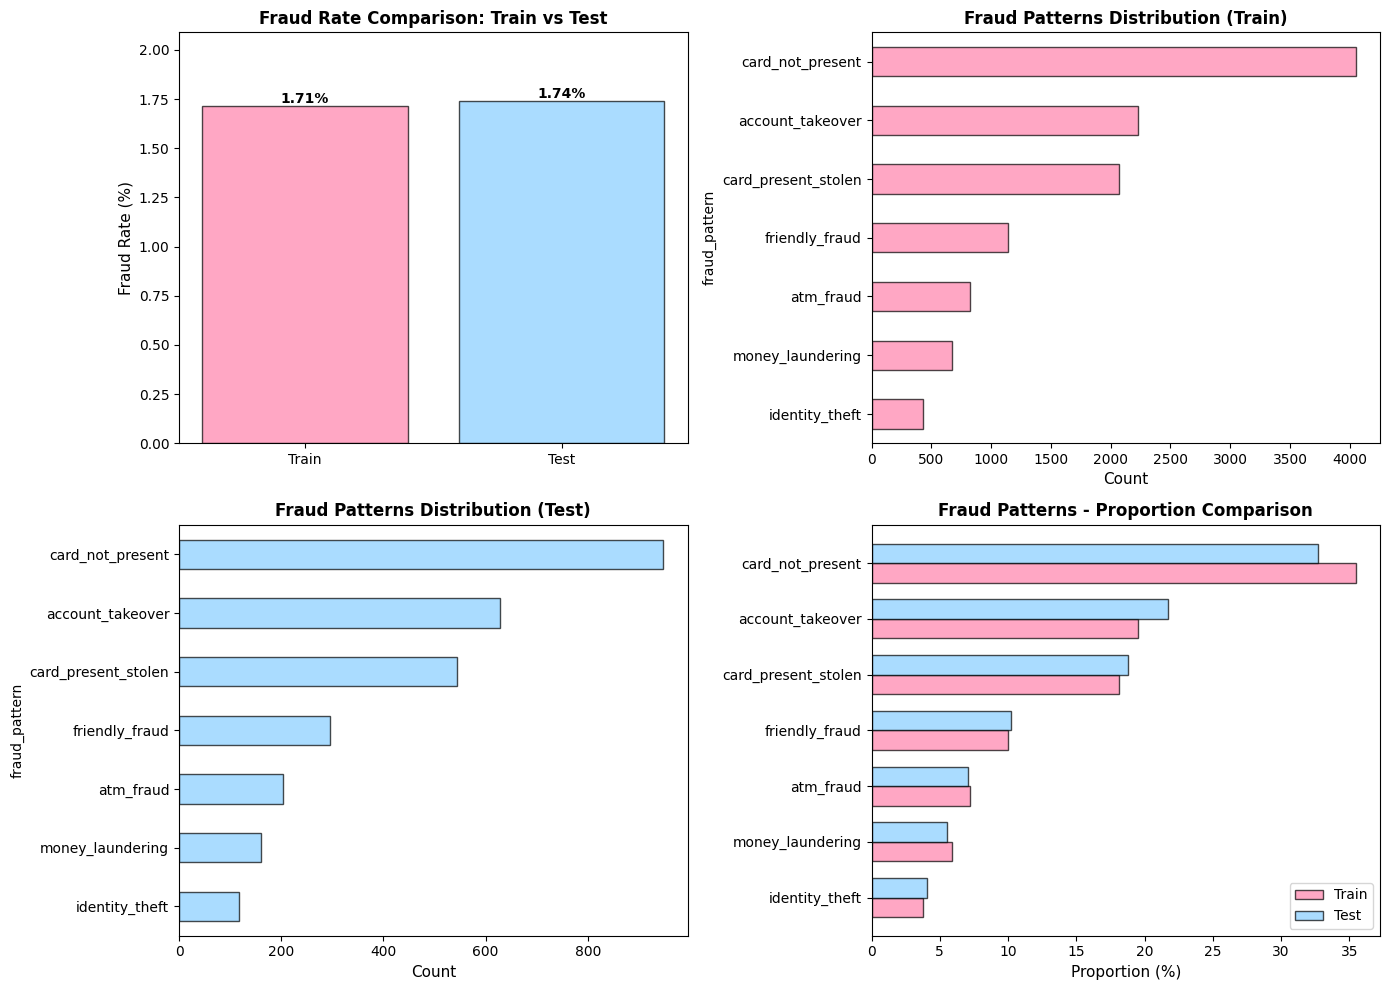


📊 FRAUD PATTERN COMPARISON
Train Fraud Patterns:
fraud_pattern
card_not_present       4050
account_takeover       2228
card_present_stolen    2068
friendly_fraud         1145
atm_fraud               823
money_laundering        672
identity_theft          432
Name: count, dtype: int64

Test Fraud Patterns:
fraud_pattern
card_not_present       948
account_takeover       629
card_present_stolen    544
friendly_fraud         295
atm_fraud              204
money_laundering       161
identity_theft         117
Name: count, dtype: int64

Train Fraud Pattern Distribution (%):
fraud_pattern
card_not_present       35.470310
account_takeover       19.513050
card_present_stolen    18.111753
friendly_fraud         10.028026
atm_fraud               7.207917
money_laundering        5.885444
identity_theft          3.783500
Name: count, dtype: float64

Test Fraud Pattern Distribution (%):
fraud_pattern
card_not_present       32.712215
account_takeover       21.704624
card_present_stolen    18.771567


In [180]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Fraud rate comparison
ax1 = axes[0, 0]
fraud_rates = [fraud_rate, fraud_rate_test]
colors = ['#FF82AB', '#87CEFF']
bars = ax1.bar(['Train', 'Test'], fraud_rates, color=colors, alpha=0.7, edgecolor='black')
ax1.set_ylabel('Fraud Rate (%)', fontsize=11)
ax1.set_title('Fraud Rate Comparison: Train vs Test', fontsize=12, fontweight='bold')
ax1.set_ylim(0, max(fraud_rates) * 1.2)
for i, bar in enumerate(bars):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
            f'{fraud_rates[i]:.2f}%', ha='center', va='bottom', fontweight='bold')

# 2. Fraud pattern distribution - Train
ax2 = axes[0, 1]
fraud_patterns_train = df[df['is_fraud']==1]['fraud_pattern'].value_counts()
fraud_patterns_train.plot(kind='barh', ax=ax2, color='#FF82AB', alpha=0.7, edgecolor='black')
ax2.set_xlabel('Count', fontsize=11)
ax2.set_title('Fraud Patterns Distribution (Train)', fontsize=12, fontweight='bold')
ax2.invert_yaxis()

# 3. Fraud pattern distribution - Test
ax3 = axes[1, 0]
fraud_patterns_test = df_test[df_test['is_fraud']==1]['fraud_pattern'].value_counts()
fraud_patterns_test.plot(kind='barh', ax=ax3, color='#87CEFF', alpha=0.7, edgecolor='black')
ax3.set_xlabel('Count', fontsize=11)
ax3.set_title('Fraud Patterns Distribution (Test)', fontsize=12, fontweight='bold')
ax3.invert_yaxis()

# 4. Fraud pattern proportions comparison
ax4 = axes[1, 1]
fraud_prop_train = (fraud_patterns_train / fraud_patterns_train.sum() * 100).sort_values(ascending=True)
fraud_prop_test = (fraud_patterns_test / fraud_patterns_test.sum() * 100).reindex(fraud_prop_train.index, fill_value=0)

x = np.arange(len(fraud_prop_train))
width = 0.35
ax4.barh(x - width/2, fraud_prop_train.values, width, label='Train', color='#FF82AB', alpha=0.7, edgecolor='black')
ax4.barh(x + width/2, fraud_prop_test.values, width, label='Test', color='#87CEFF', alpha=0.7, edgecolor='black')
ax4.set_yticks(x)
ax4.set_yticklabels(fraud_prop_train.index)
ax4.set_xlabel('Proportion (%)', fontsize=11)
ax4.set_title('Fraud Patterns - Proportion Comparison', fontsize=12, fontweight='bold')
ax4.legend()

plt.tight_layout()
plt.show()

# Summary statistics
print(f'\n📊 FRAUD PATTERN COMPARISON\n' + '='*50)
print(f'Train Fraud Patterns:\n{fraud_patterns_train}\n')
print(f'Test Fraud Patterns:\n{fraud_patterns_test}\n')
print(f'Train Fraud Pattern Distribution (%):\n{fraud_prop_train.sort_values(ascending=False)}\n')
print(f'Test Fraud Pattern Distribution (%):\n{fraud_prop_test.sort_values(ascending=False)}')

As most of fraud detection problems, dataset has **massive imbalance label**, when fraud transaction only has part of approximately 1.7% in both train and test datasets.

Fraud parttern distribution maintains during time interval of train and test.

## **5. Numerical EDA**

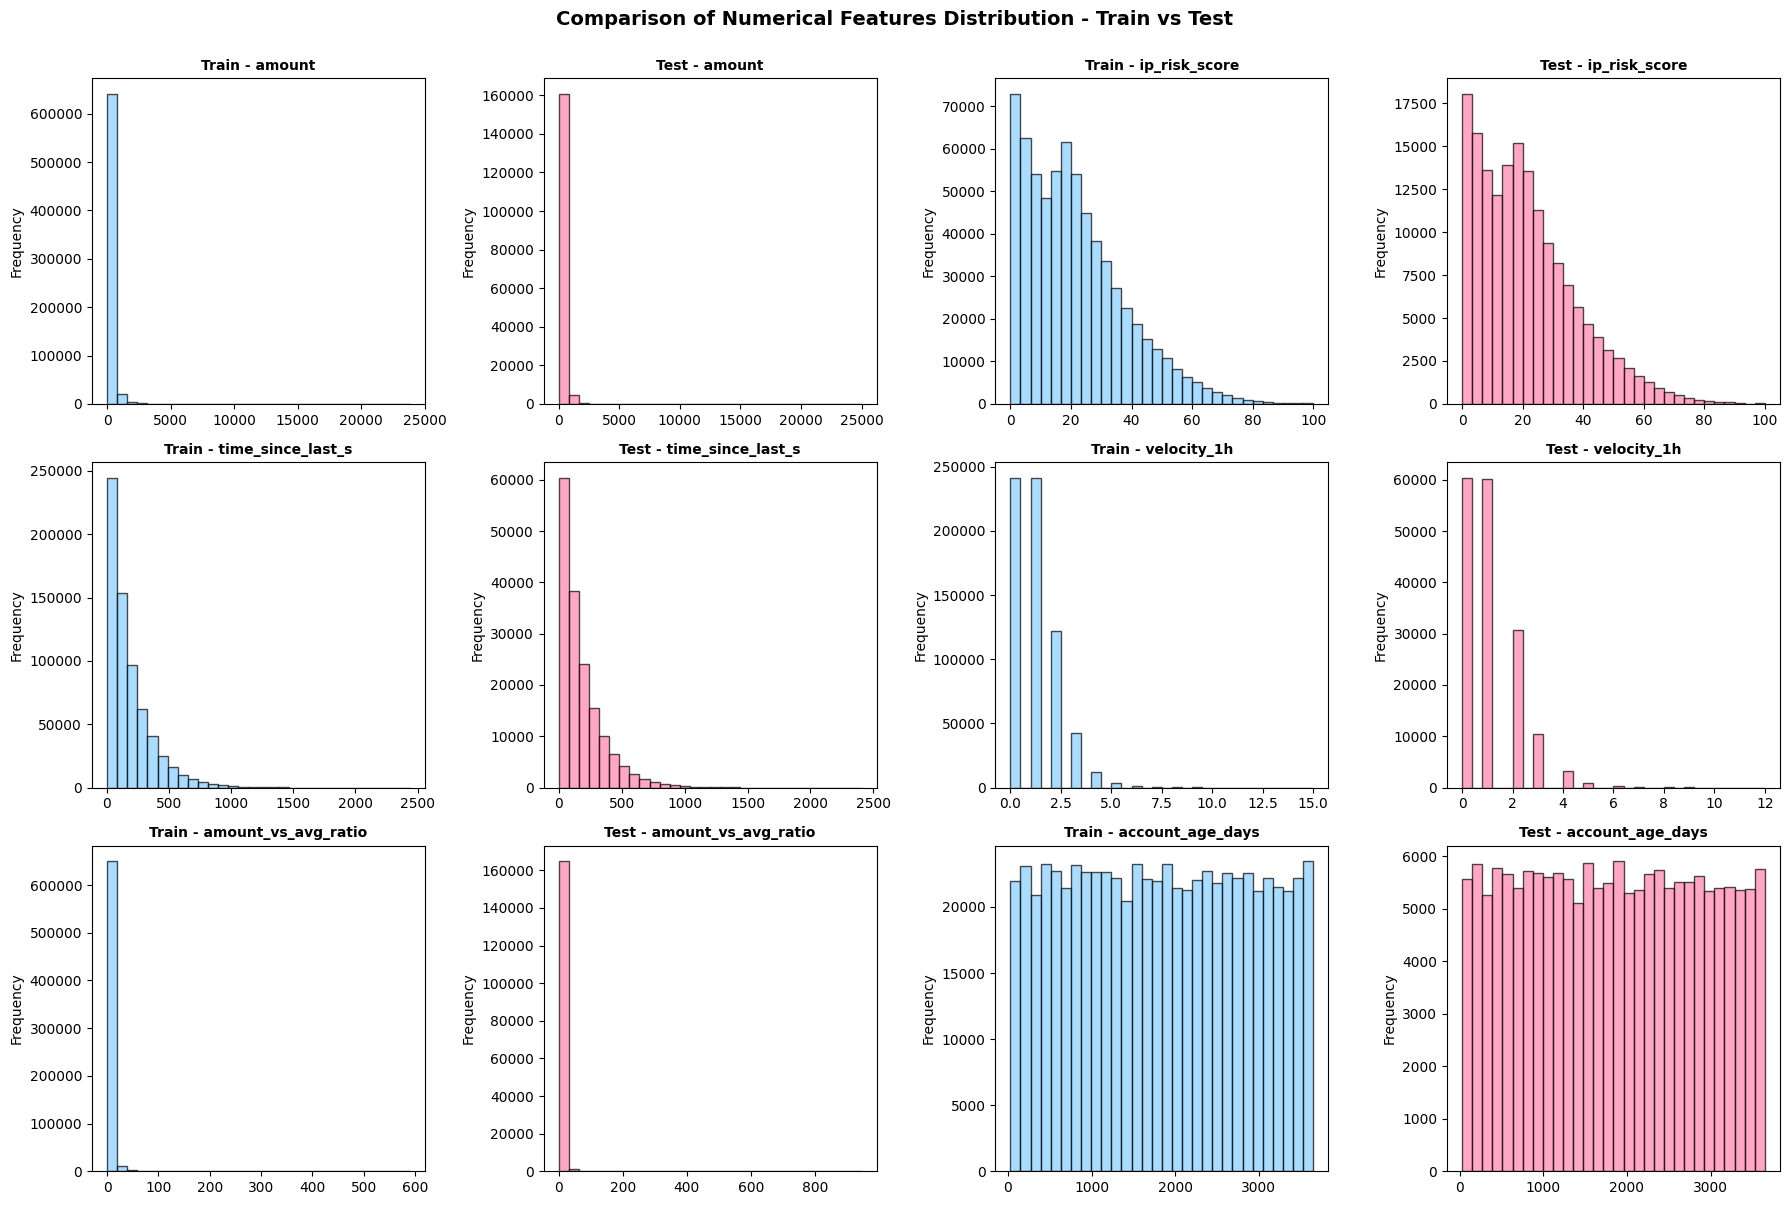

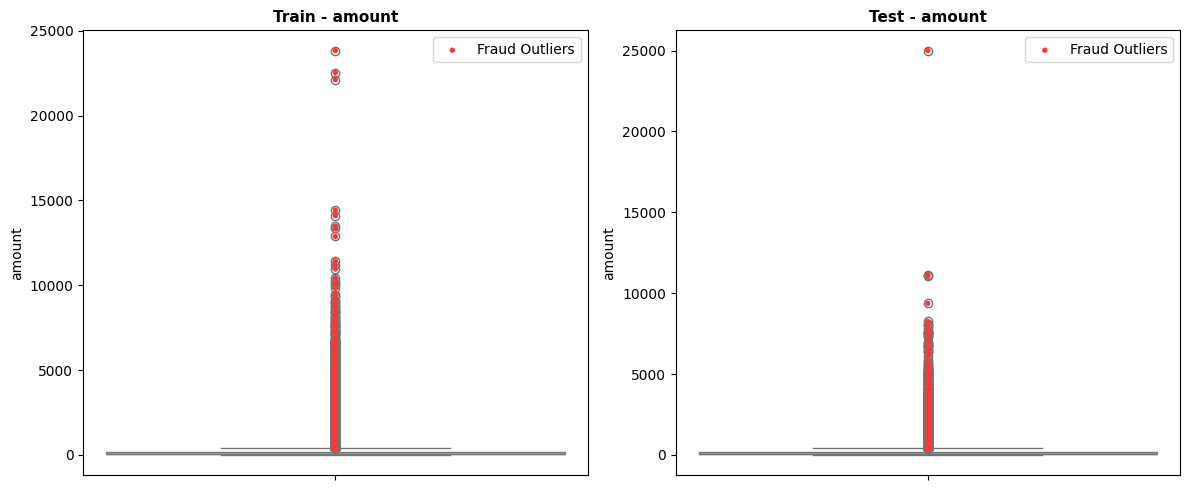

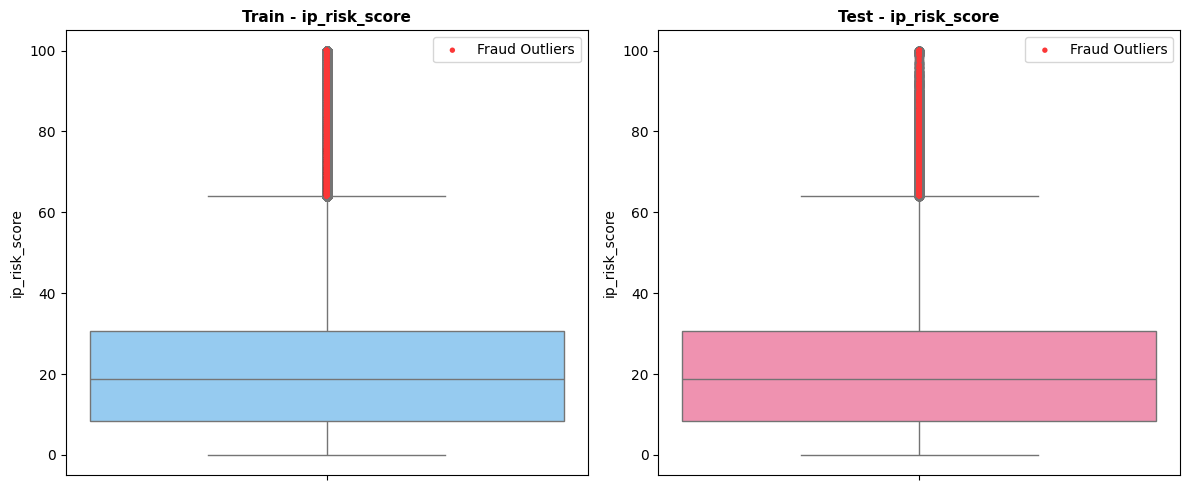

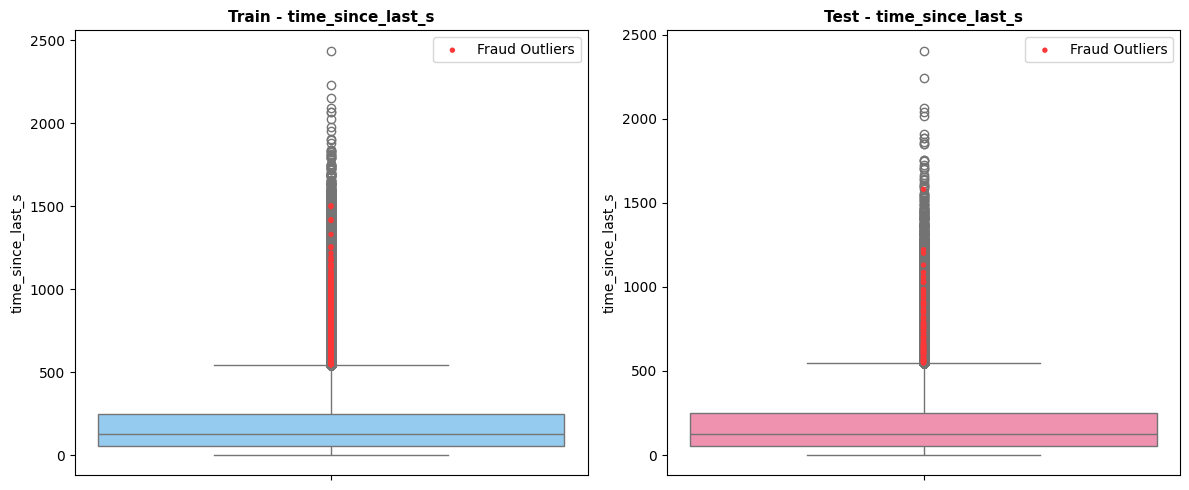

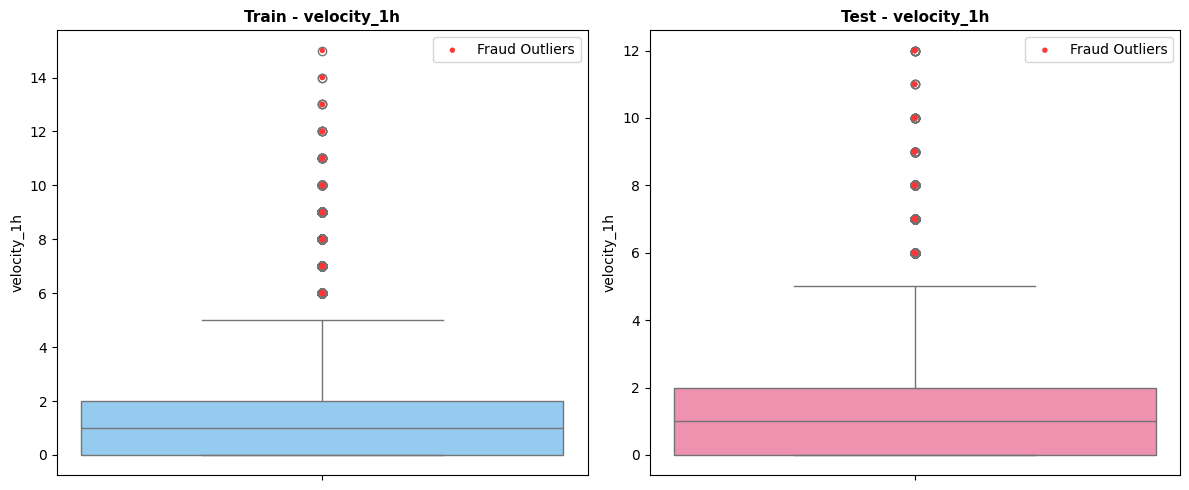

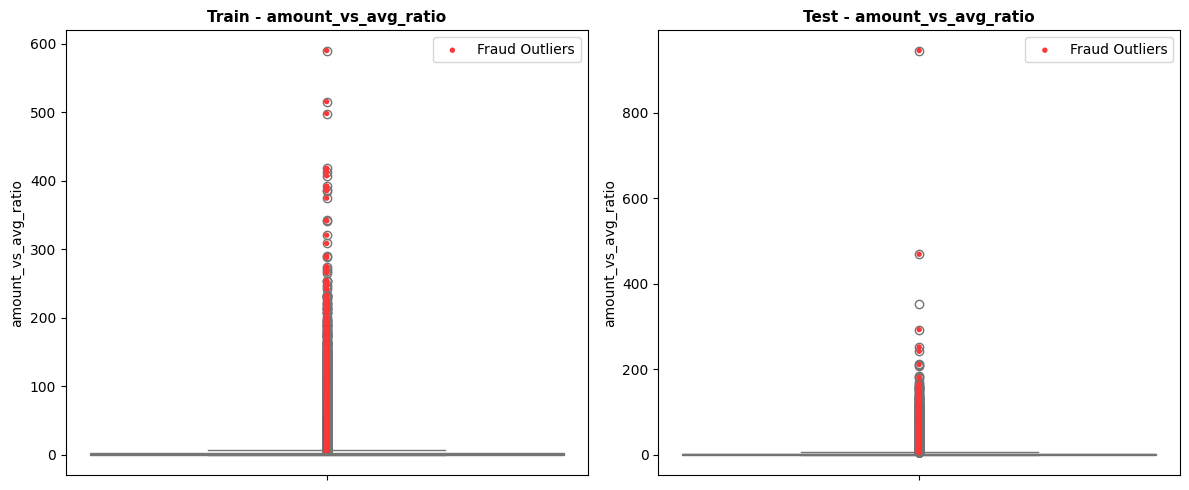

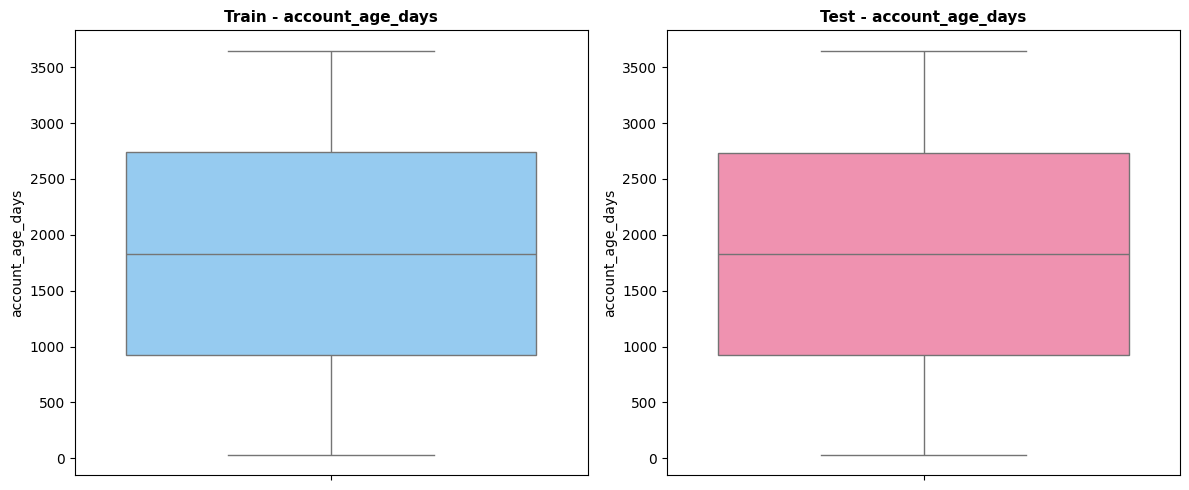

In [22]:
num_cols = [
    'amount',
    'ip_risk_score',
    'time_since_last_s',
    'velocity_1h',
    'amount_vs_avg_ratio',
    'account_age_days'
]

# Function to identify outliers using boxplot logic
def get_outliers(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = (data[column] < lower_bound) | (data[column] > upper_bound)
    return outliers

# Side-by-side comparison for each numerical column
fig, axes = plt.subplots(3, 4, figsize=(18, 12))
axes = axes.flatten()

for idx, col in enumerate(num_cols):
    # Train histogram
    axes[idx*2].hist(df[col], bins=30, color='#87CEFF', edgecolor='black', alpha=0.7)
    axes[idx*2].set_title(f'Train - {col}', fontsize=10, fontweight='bold')
    axes[idx*2].set_ylabel('Frequency')
    
    # Test histogram
    axes[idx*2 + 1].hist(df_test[col], bins=30, color='#FF82AB', edgecolor='black', alpha=0.7)
    axes[idx*2 + 1].set_title(f'Test - {col}', fontsize=10, fontweight='bold')
    axes[idx*2 + 1].set_ylabel('Frequency')

plt.suptitle('Comparison of Numerical Features Distribution - Train vs Test', fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

# Side-by-side boxplots for each numerical column with fraud outliers highlighted
for col in num_cols:
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    # Train boxplot with fraud outliers
    sns.boxplot(data=df, y=col, ax=axes[0], color='#87CEFF')
    train_outliers = get_outliers(df, col)
    train_fraud_outliers = df[train_outliers & (df['is_fraud'] == 1)]
    if len(train_fraud_outliers) > 0:
        axes[0].scatter(x=[0] * len(train_fraud_outliers), y=train_fraud_outliers[col], 
                       color="#FB3737", s=15, marker='o', edgecolors='none', label='Fraud Outliers', zorder=3)
        axes[0].legend()
    axes[0].set_title(f'Train - {col}', fontsize=11, fontweight='bold')
    
    # Test boxplot with fraud outliers
    sns.boxplot(data=df_test, y=col, ax=axes[1], color='#FF82AB')
    test_outliers = get_outliers(df_test, col)
    test_fraud_outliers = df_test[test_outliers & (df_test['is_fraud'] == 1)]
    if len(test_fraud_outliers) > 0:
        axes[1].scatter(x=[0] * len(test_fraud_outliers), y=test_fraud_outliers[col], 
                       color="#FB3737", s=15, marker='o', edgecolors='none', label='Fraud Outliers', zorder=3)
        axes[1].legend()
    axes[1].set_title(f'Test - {col}', fontsize=11, fontweight='bold')
    
    plt.tight_layout()
    plt.show()


Almost feature consistently keep the **right-skew distributions** through train and test data set.

There are some numerical features that contain **many outlier values** but it should be not eliminated because of large part of them is fraud transactions.

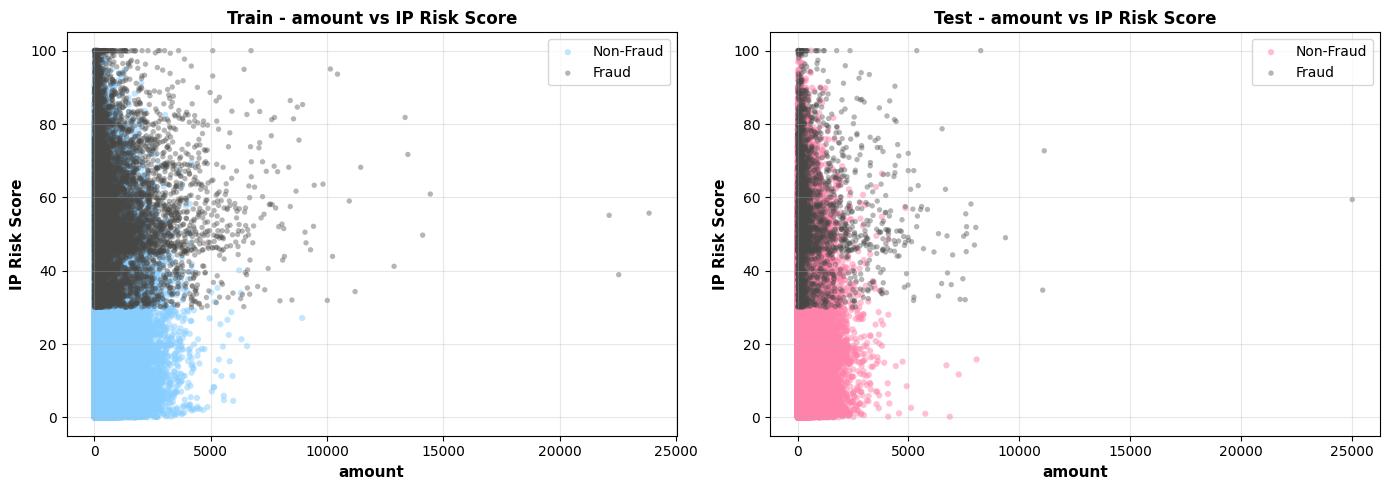

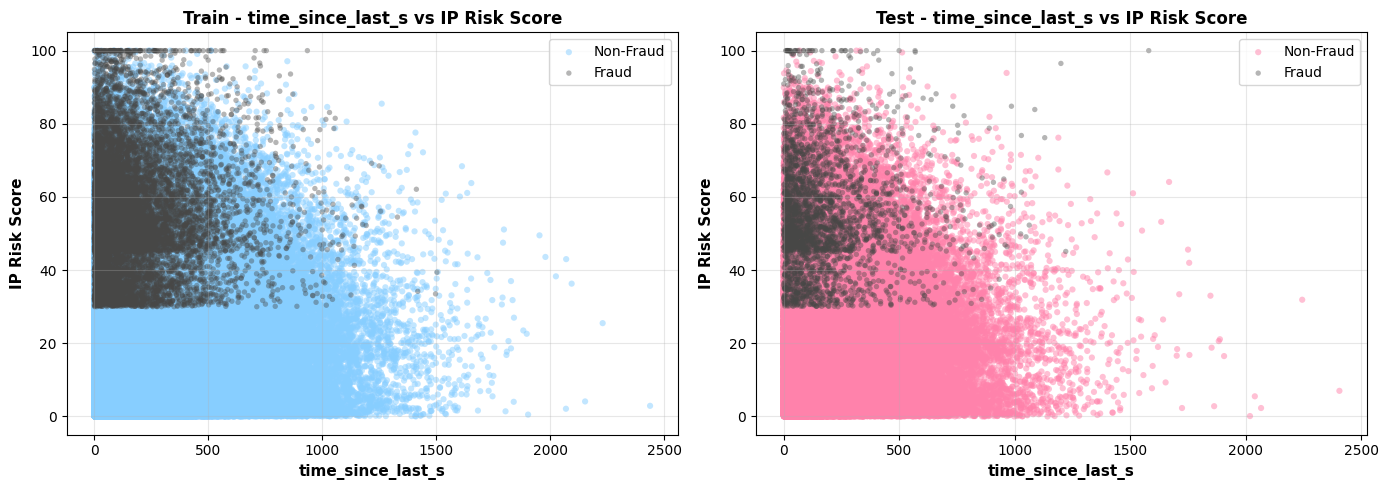

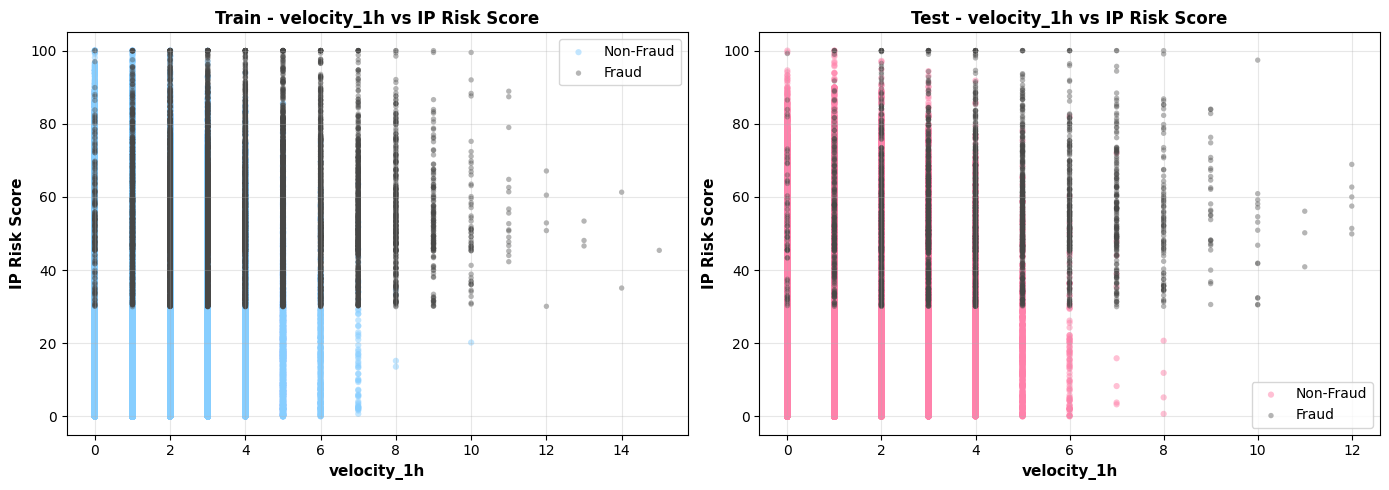

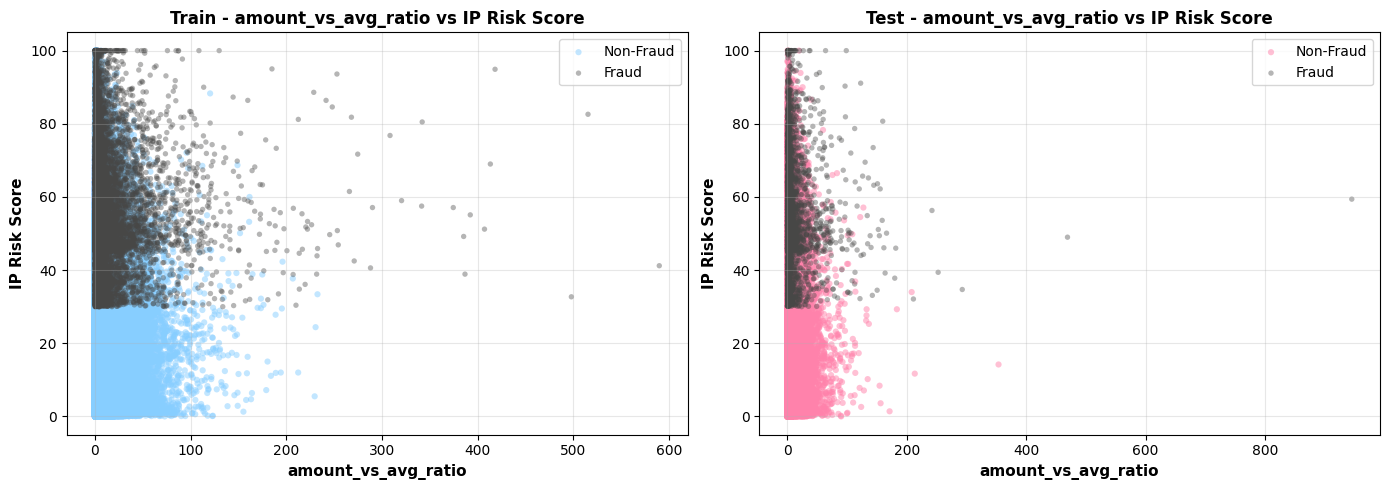

C:\Users\ASUS\AppData\Local\Temp\ipykernel_18860\3288141748.py:36: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()


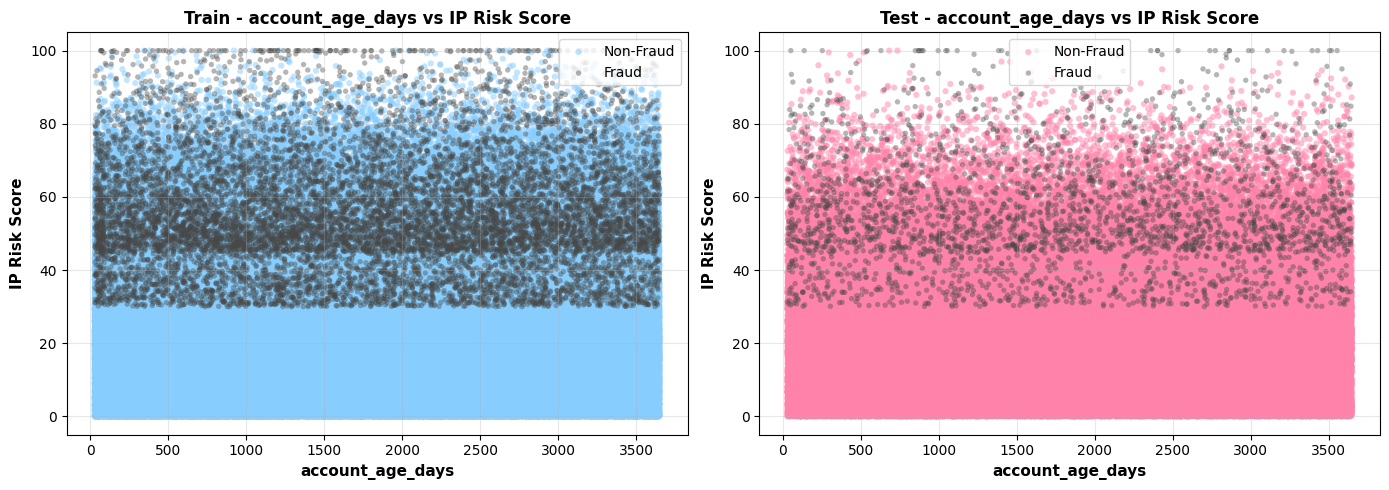

In [18]:
# Scatter plots - each numerical column vs ip_risk_score
for col in num_cols:
    if col == 'ip_risk_score':
        continue
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Train scatter plot
    non_fraud_train = df[df['is_fraud'] == 0]
    fraud_train = df[df['is_fraud'] == 1]
    
    axes[0].scatter(non_fraud_train[col], non_fraud_train['ip_risk_score'], 
                   alpha=0.5, s=20, label='Non-Fraud', color='#87CEFF', edgecolors='none')
    axes[0].scatter(fraud_train[col], fraud_train['ip_risk_score'], 
                   alpha=0.4, s=15, label='Fraud', color="#474746", marker='o', edgecolors='none')
    axes[0].set_xlabel(col, fontsize=11, fontweight='bold')
    axes[0].set_ylabel('IP Risk Score', fontsize=11, fontweight='bold')
    axes[0].set_title(f'Train - {col} vs IP Risk Score', fontsize=12, fontweight='bold')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # Test scatter plot
    non_fraud_test = df_test[df_test['is_fraud'] == 0]
    fraud_test = df_test[df_test['is_fraud'] == 1]
    
    axes[1].scatter(non_fraud_test[col], non_fraud_test['ip_risk_score'], 
                   alpha=0.5, s=20, label='Non-Fraud', color='#FF82AB', edgecolors='none')
    axes[1].scatter(fraud_test[col], fraud_test['ip_risk_score'], 
                   alpha=0.4, s=15, label='Fraud', color="#474746", marker='o', edgecolors='none')
    axes[1].set_xlabel(col, fontsize=11, fontweight='bold')
    axes[1].set_ylabel('IP Risk Score', fontsize=11, fontweight='bold')
    axes[1].set_title(f'Test - {col} vs IP Risk Score', fontsize=12, fontweight='bold')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()


`ip_risk_score`, `amount`, `time_since_last_s`, `velocity` may have effects on prediction fraud detection, with `ip_risk_score` seemly has the most robust contribution.

## **6. Categorical EDA**


===== merchant_category =====

Train - Top 10:
merchant_category
grocery          120252
online_retail    100051
restaurant        80026
gas_station       53377
atm               53064
clothing          46440
pharmacy          40289
electronics       40051
hotel             33012
travel            32759
Name: count, dtype: int64

Test - Top 10:
merchant_category
grocery          30007
online_retail    24966
restaurant       20115
gas_station      13253
atm              13213
clothing         11764
electronics      10027
pharmacy          9932
travel            8282
hotel             8276
Name: count, dtype: int64
--------------------------------------------------

===== merchant_country =====

Train - Top 10:
merchant_country
US    470367
CA     26305
GB     26172
FR     25996
DE     25989
AU     25874
RO     13342
NG     13137
CN     13085
BR     12978
Name: count, dtype: int64

Test - Top 10:
merchant_country
US    117322
DE      6652
FR      6563
GB      6551
AU      6512
CA      6

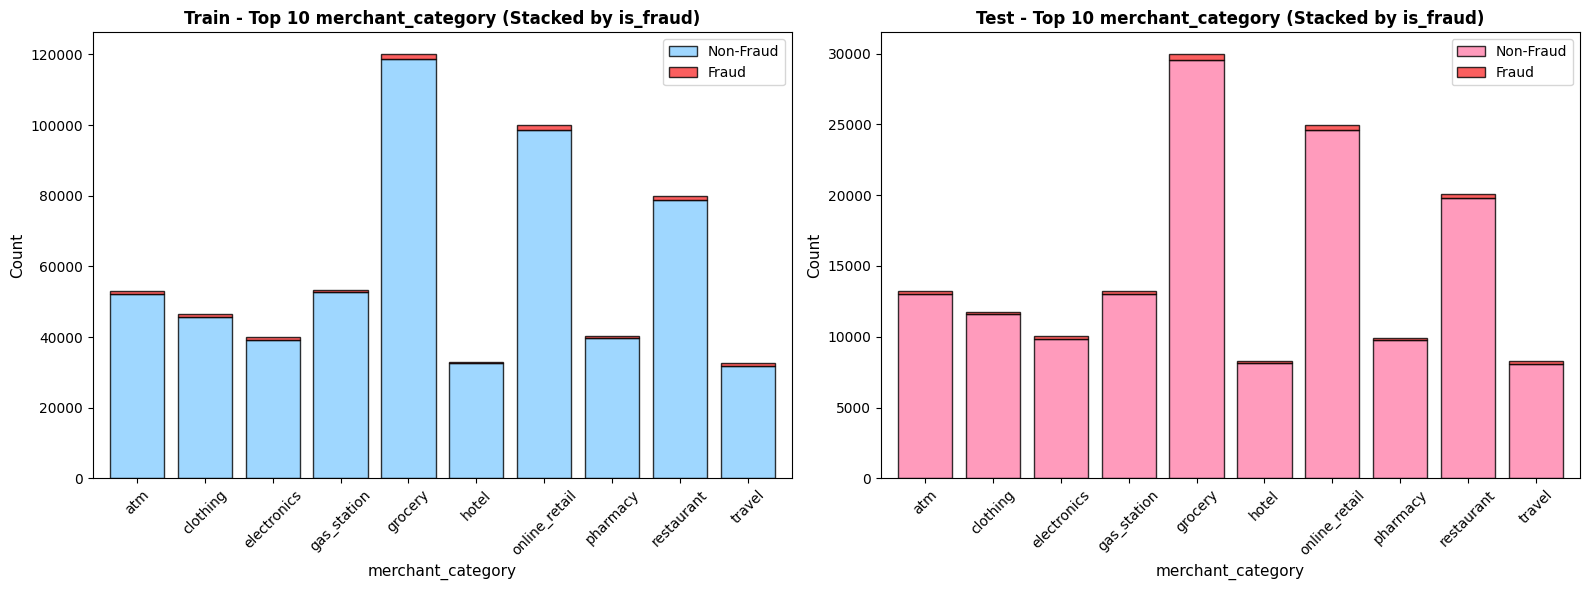

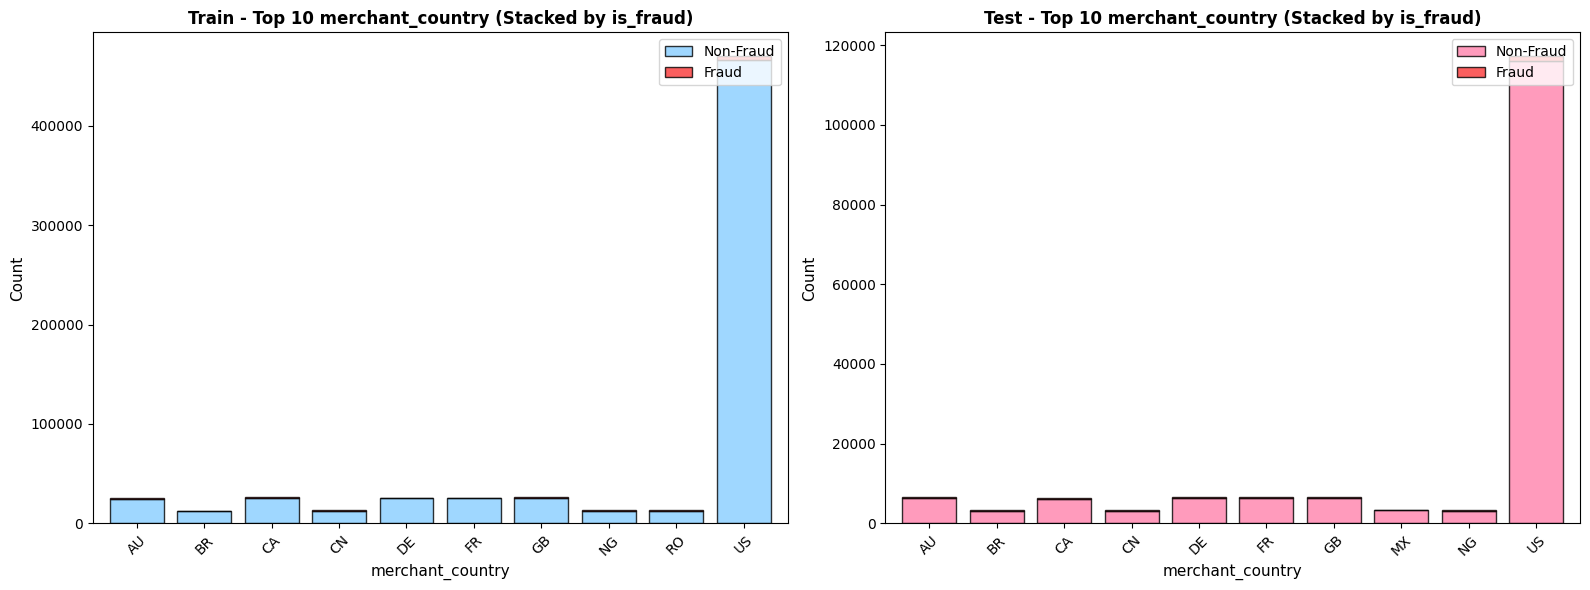

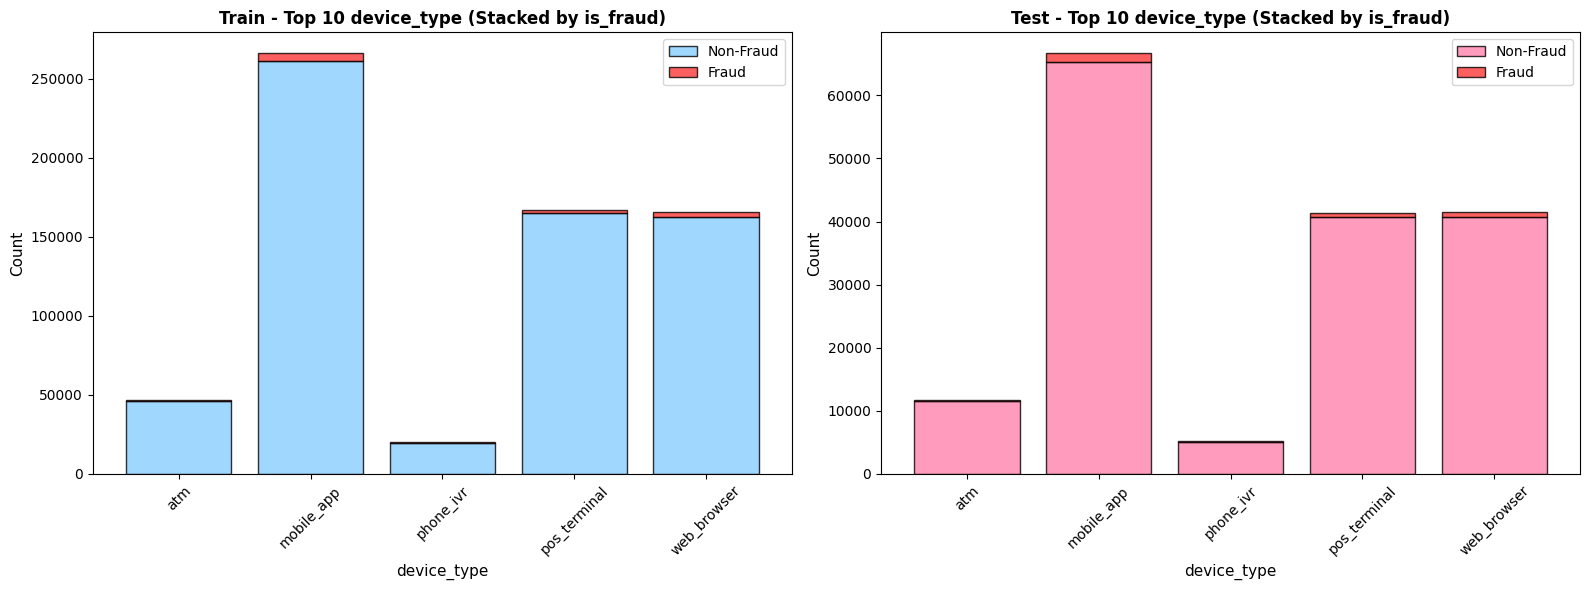

In [24]:
cat_cols = ['merchant_category', 'merchant_country', 'device_type']

# Print statistics for train and test
for col in cat_cols:
    print(f'\n===== {col} =====')
    print(f'\nTrain - Top 10:')
    print(df[col].value_counts().head(10))
    print(f'\nTest - Top 10:')
    print(df_test[col].value_counts().head(10))
    print('-'*50)

# Plot train and test side-by-side - True Stacked column charts by is_fraud
for col in cat_cols:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Train stacked column chart
    top_10_train = df[col].value_counts().head(10).index
    train_data = df[df[col].isin(top_10_train)].groupby([col, 'is_fraud']).size().unstack(fill_value=0)
    train_data.plot(kind='bar', stacked=True, ax=axes[0], color=['#87CEFF', '#FB3737'], alpha=0.8, edgecolor='black', width=0.8)
    axes[0].set_title(f'Train - Top 10 {col} (Stacked by is_fraud)', fontsize=12, fontweight='bold')
    axes[0].set_xlabel(col, fontsize=11)
    axes[0].set_ylabel('Count', fontsize=11)
    axes[0].legend(['Non-Fraud', 'Fraud'], loc='upper right')
    axes[0].tick_params(axis='x', rotation=45)
    
    # Test stacked column chart
    top_10_test = df_test[col].value_counts().head(10).index
    test_data = df_test[df_test[col].isin(top_10_test)].groupby([col, 'is_fraud']).size().unstack(fill_value=0)
    test_data.plot(kind='bar', stacked=True, ax=axes[1], color=['#FF82AB', '#FB3737'], alpha=0.8, edgecolor='black', width=0.8)
    axes[1].set_title(f'Test - Top 10 {col} (Stacked by is_fraud)', fontsize=12, fontweight='bold')
    axes[1].set_xlabel(col, fontsize=11)
    axes[1].set_ylabel('Count', fontsize=11)
    axes[1].legend(['Non-Fraud', 'Fraud'], loc='upper right')
    axes[1].tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.show()


The distributions of categorical features have **minority differnces** and **keep consistently** through train and test. 

## **7. Fraud Rate according to Category**

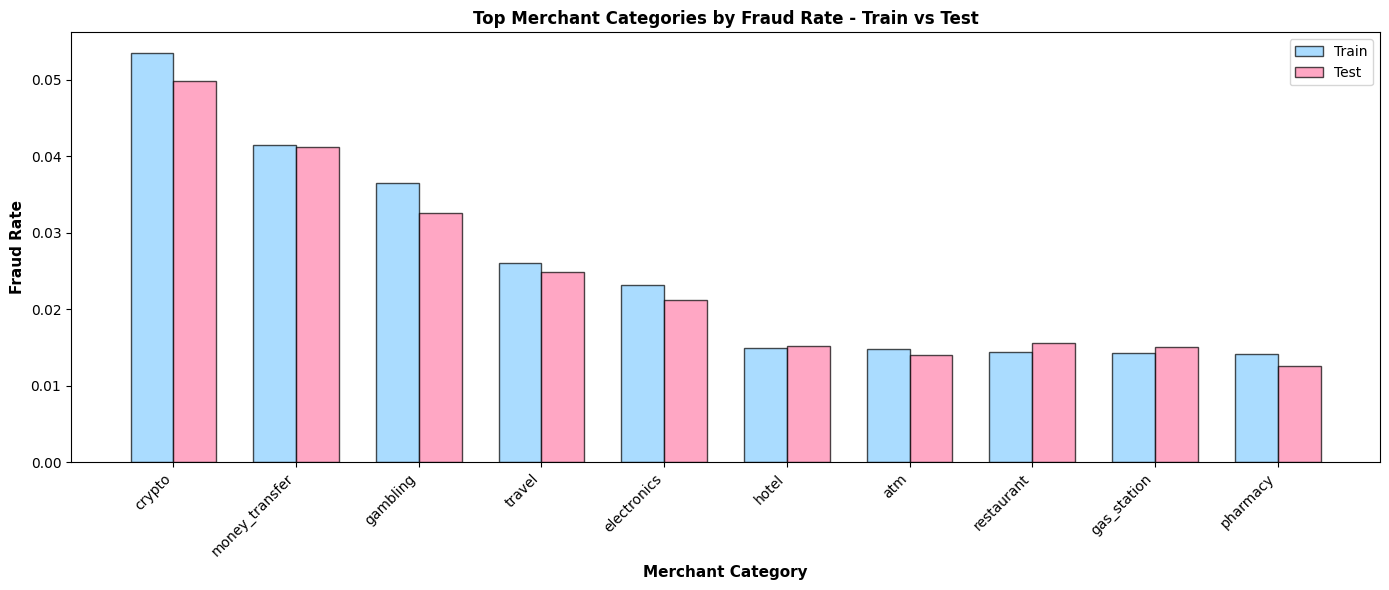

In [183]:
merchant_fraud_train = (
    df.groupby('merchant_category')['is_fraud']
      .mean()
      .sort_values(ascending=False)
)
merchant_fraud_test = (
    df_test.groupby('merchant_category')['is_fraud']
      .mean()
      .sort_values(ascending=False)
)

# Get top 10 from train, align test to same categories
top_10_categories = merchant_fraud_train.head(10).index
train_vals = merchant_fraud_train[top_10_categories]
test_vals = merchant_fraud_test.reindex(top_10_categories, fill_value=0)

fig, ax = plt.subplots(figsize=(14, 6))
x = np.arange(len(top_10_categories))
width = 0.35

ax.bar(x - width/2, train_vals.values, width, label='Train', color='#87CEFF', edgecolor='black', alpha=0.7)
ax.bar(x + width/2, test_vals.values, width, label='Test', color='#FF82AB', edgecolor='black', alpha=0.7)

ax.set_xlabel('Merchant Category', fontsize=11, fontweight='bold')
ax.set_ylabel('Fraud Rate', fontsize=11, fontweight='bold')
ax.set_title('Top Merchant Categories by Fraud Rate - Train vs Test', fontsize=12, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(top_10_categories, rotation=45, ha='right')
ax.legend()



plt.tight_layout()

### **7.1. Fraud Rate by Merchant Country**

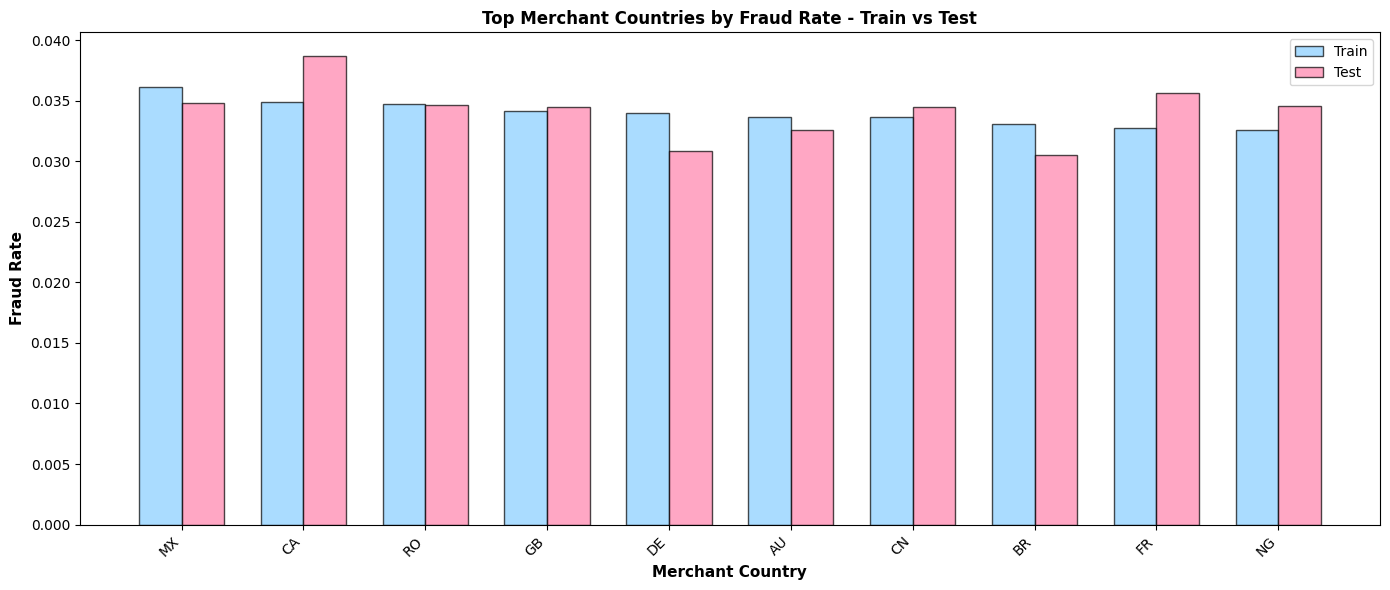

In [184]:
merchant_country_fraud_train = (
    df.groupby('merchant_country')['is_fraud']
      .mean()
      .sort_values(ascending=False)
)
merchant_country_fraud_test = (
    df_test.groupby('merchant_country')['is_fraud']
      .mean()
      .sort_values(ascending=False)
)

# Get top 10 from train, align test to same categories
top_10_countries = merchant_country_fraud_train.head(10).index
train_vals = merchant_country_fraud_train[top_10_countries]
test_vals = merchant_country_fraud_test.reindex(top_10_countries, fill_value=0)

fig, ax = plt.subplots(figsize=(14, 6))
x = np.arange(len(top_10_countries))
width = 0.35

ax.bar(x - width/2, train_vals.values, width, label='Train', color='#87CEFF', edgecolor='black', alpha=0.7)
ax.bar(x + width/2, test_vals.values, width, label='Test', color='#FF82AB', edgecolor='black', alpha=0.7)

ax.set_xlabel('Merchant Country', fontsize=11, fontweight='bold')
ax.set_ylabel('Fraud Rate', fontsize=11, fontweight='bold')
ax.set_title('Top Merchant Countries by Fraud Rate - Train vs Test', fontsize=12, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(top_10_countries, rotation=45, ha='right')
ax.legend()



plt.tight_layout()

### **7.2. Fraud Rate by Device Type**

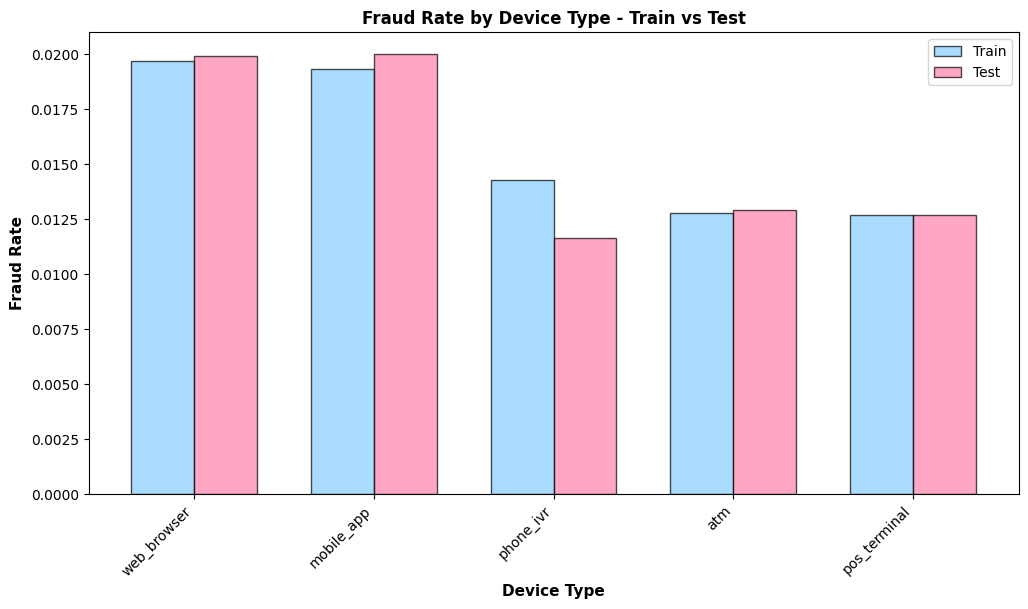

<Figure size 1000x500 with 0 Axes>

In [185]:
device_type_fraud_train = (
    df.groupby('device_type')['is_fraud']
      .mean()
      .sort_values(ascending=False)
)
device_type_fraud_test = (
    df_test.groupby('device_type')['is_fraud']
      .mean()
      .sort_values(ascending=False)
)

# Align test to train categories
train_vals = device_type_fraud_train
test_vals = device_type_fraud_test.reindex(device_type_fraud_train.index, fill_value=0)

fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(device_type_fraud_train))
width = 0.35

ax.bar(x - width/2, train_vals.values, width, label='Train', color='#87CEFF', edgecolor='black', alpha=0.7)
ax.bar(x + width/2, test_vals.values, width, label='Test', color='#FF82AB', edgecolor='black', alpha=0.7)

ax.set_xlabel('Device Type', fontsize=11, fontweight='bold')
ax.set_ylabel('Fraud Rate', fontsize=11, fontweight='bold')
ax.set_title('Fraud Rate by Device Type - Train vs Test', fontsize=12, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(train_vals.index, rotation=45, ha='right')
ax.legend()


plt.show()
plt.tight_layout()

The proportions of fraud and non-fraud between categorical features have **minority differnces** and **keep consistently** through train and test.

## **9. Time-based EDA**

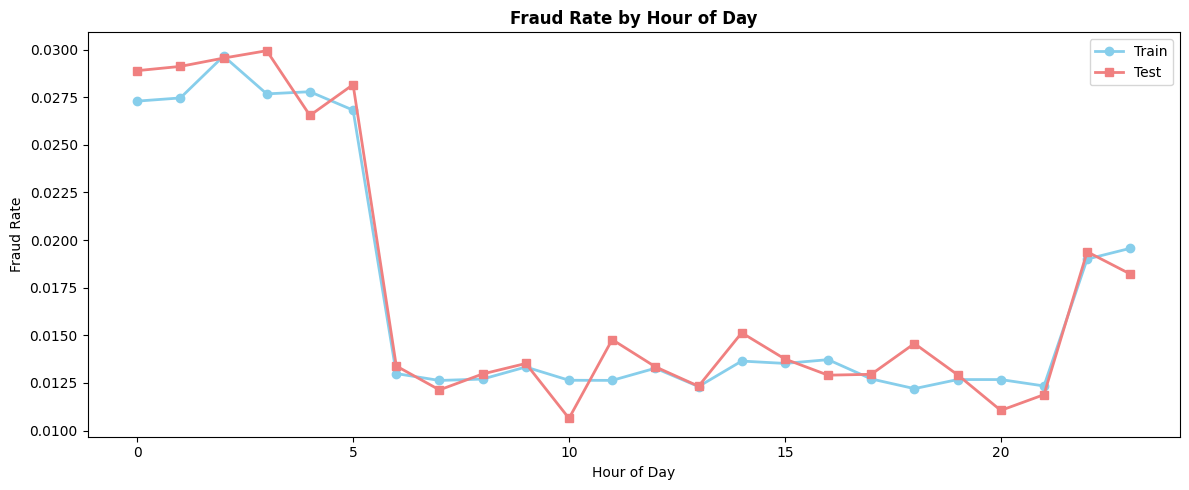

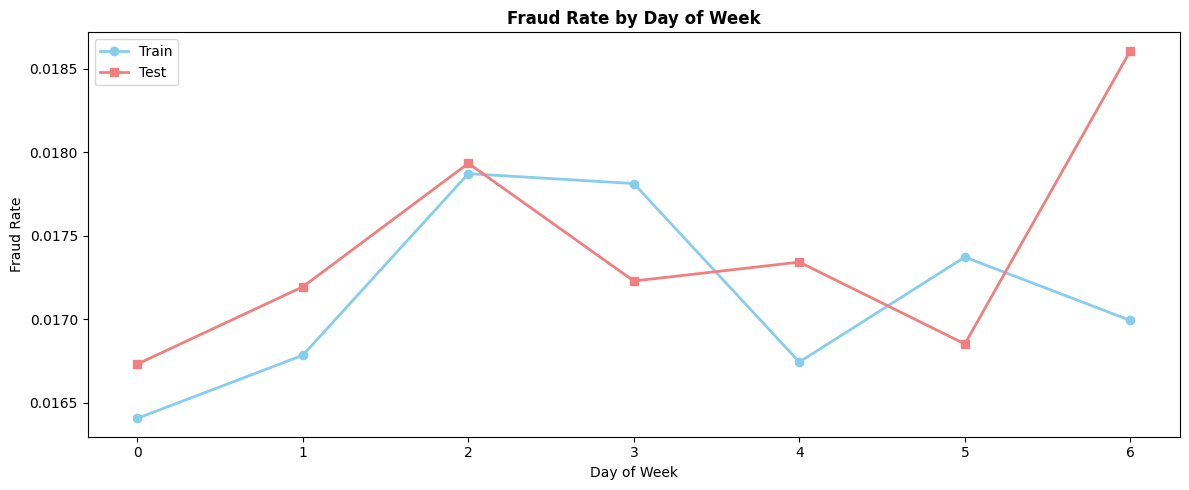

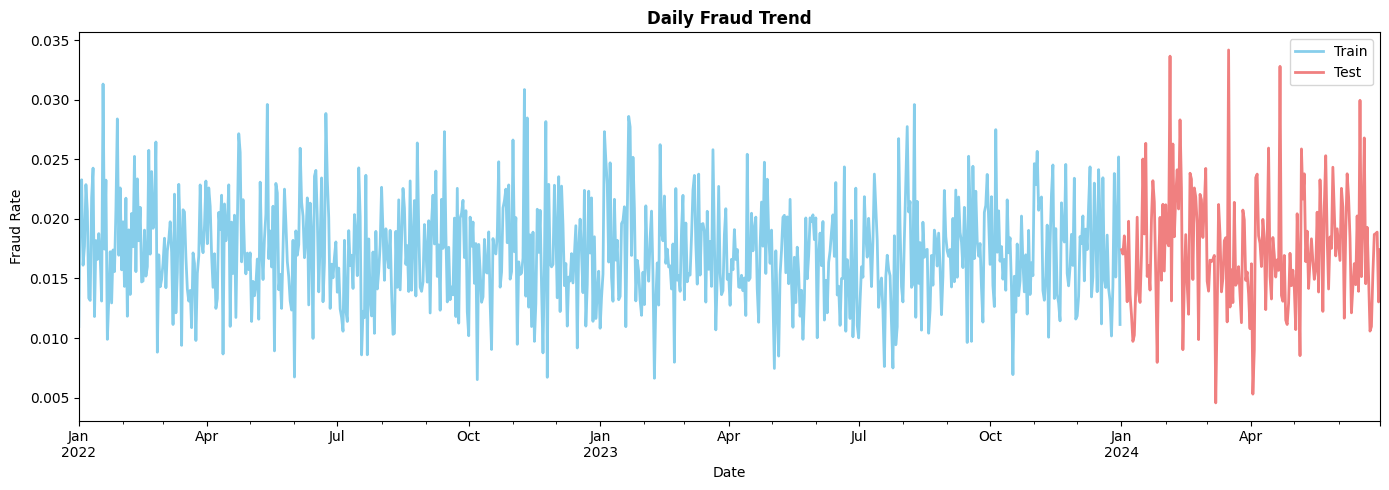

In [186]:
# Fraud Rate by Hour
fig, ax = plt.subplots(figsize=(12, 5))
df.groupby('hour_of_day')['is_fraud'].mean().plot(marker='o', ax=ax, label='Train', color='skyblue', linewidth=2)
df_test.groupby('hour_of_day')['is_fraud'].mean().plot(marker='s', ax=ax, label='Test', color='lightcoral', linewidth=2)
ax.set_title('Fraud Rate by Hour of Day', fontsize=12, fontweight='bold')
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Fraud Rate')
ax.legend()
plt.tight_layout()
plt.show()

# Fraud Rate by Day of Week
fig, ax = plt.subplots(figsize=(12, 5))
df.groupby('day_of_week')['is_fraud'].mean().plot(marker='o', ax=ax, label='Train', color='skyblue', linewidth=2)
df_test.groupby('day_of_week')['is_fraud'].mean().plot(marker='s', ax=ax, label='Test', color='lightcoral', linewidth=2)
ax.set_title('Fraud Rate by Day of Week', fontsize=12, fontweight='bold')
ax.set_xlabel('Day of Week')
ax.set_ylabel('Fraud Rate')
ax.legend()
plt.tight_layout()
plt.show()

# Daily Fraud Trend
fig, ax = plt.subplots(figsize=(14, 5))
daily_fraud_train = df.resample('D')['is_fraud'].mean()
daily_fraud_test = df_test.resample('D')['is_fraud'].mean()
daily_fraud_train.plot(ax=ax, label='Train', color='skyblue', linewidth=2)
daily_fraud_test.plot(ax=ax, label='Test', color='lightcoral', linewidth=2)
ax.set_title('Daily Fraud Trend', fontsize=12, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Fraud Rate')
ax.legend()
plt.tight_layout()
plt.show()

Almost fraud transactions are implemented **in night time** and the proportions of fraud **on Wednesday** is maintained at the high level compared with others. Howerver, the test test witnesses a sharp increasing of the number of fraud transactions on **Sunday**.

It is considerable to check **fraud rate of days in month**.

## **10. Correlation + Leakage Check**

In [187]:
corr = df.corr(numeric_only=True)['is_fraud'].sort_values(ascending=False)
print(corr)
print('-'*50)

corr_test = df_test.corr(numeric_only=True)['is_fraud'].sort_values(ascending=False)
print(corr_test)

is_fraud               1.000000
velocity_1h            0.350823
ip_risk_score          0.273906
amount                 0.229365
amount_vs_avg_ratio    0.184991
is_foreign_txn         0.083412
day_of_week            0.000989
time_since_last_s      0.000663
is_weekend             0.000200
credit_limit          -0.002001
account_age_days      -0.002578
mcc_code              -0.007375
has_2fa               -0.018476
card_present          -0.024346
hour_of_day           -0.031161
device_known          -0.186914
Name: is_fraud, dtype: float64
--------------------------------------------------
is_fraud               1.000000
velocity_1h            0.353309
ip_risk_score          0.276540
amount                 0.217934
amount_vs_avg_ratio    0.175502
is_foreign_txn         0.083115
day_of_week            0.002379
is_weekend             0.001532
account_age_days       0.000018
time_since_last_s     -0.000655
credit_limit          -0.001206
mcc_code              -0.008766
has_2fa               

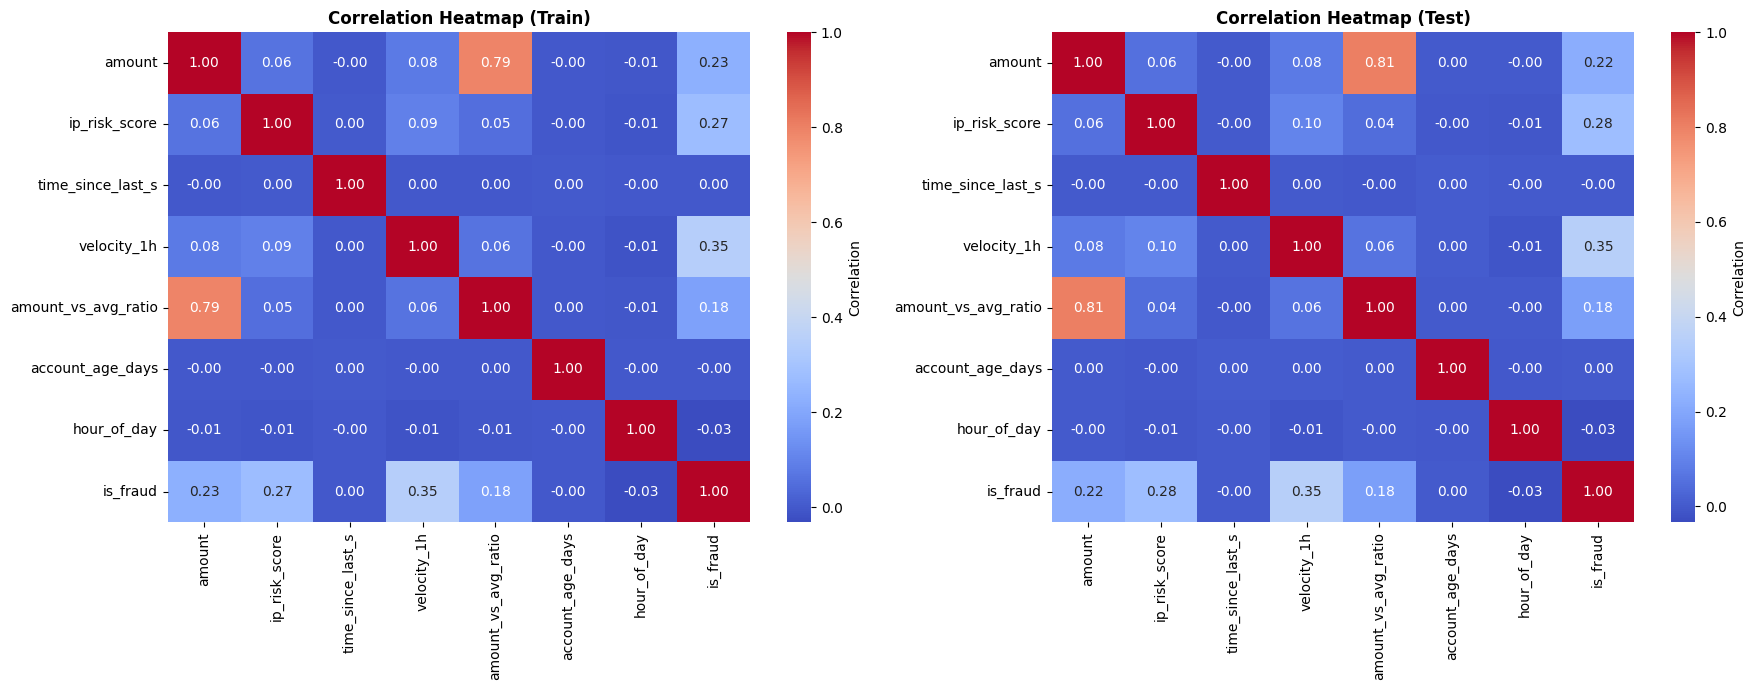

In [188]:
num_corr_cols = [
    'amount', 'ip_risk_score', 'time_since_last_s',
    'velocity_1h', 'amount_vs_avg_ratio',
    'account_age_days', 'hour_of_day', 'is_fraud'
]

corr_matrix_train = df[num_corr_cols].corr()
corr_matrix_test = df_test[num_corr_cols].corr()

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Train heatmap
sns.heatmap(corr_matrix_train, annot=True, fmt='.2f', cmap='coolwarm', ax=axes[0], cbar_kws={'label': 'Correlation'})
axes[0].set_title('Correlation Heatmap (Train)', fontsize=12, fontweight='bold')

# Test heatmap
sns.heatmap(corr_matrix_test, annot=True, fmt='.2f', cmap='coolwarm', ax=axes[1], cbar_kws={'label': 'Correlation'})
axes[1].set_title('Correlation Heatmap (Test)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

- The correlation structures between the Train and Test sets are nearly identical, ensuring high model stability.

- A strong correlation of approximately 0.80 exists between amount and amount_vs_avg_ratio, indicating significant feature redundancy.

- velocity_1h, ip_risk_score, and amount exhibit the strongest positive correlations with the target variable is_fraud.

- account_age_days and hour_of_day show near-zero correlation coefficients, suggesting minimal linear predictive power for fraud detection.

- The minimal variance in coefficients between datasets confirms that the underlying predictive signals are consistent and robust.

## **11. Business Rule Validation**

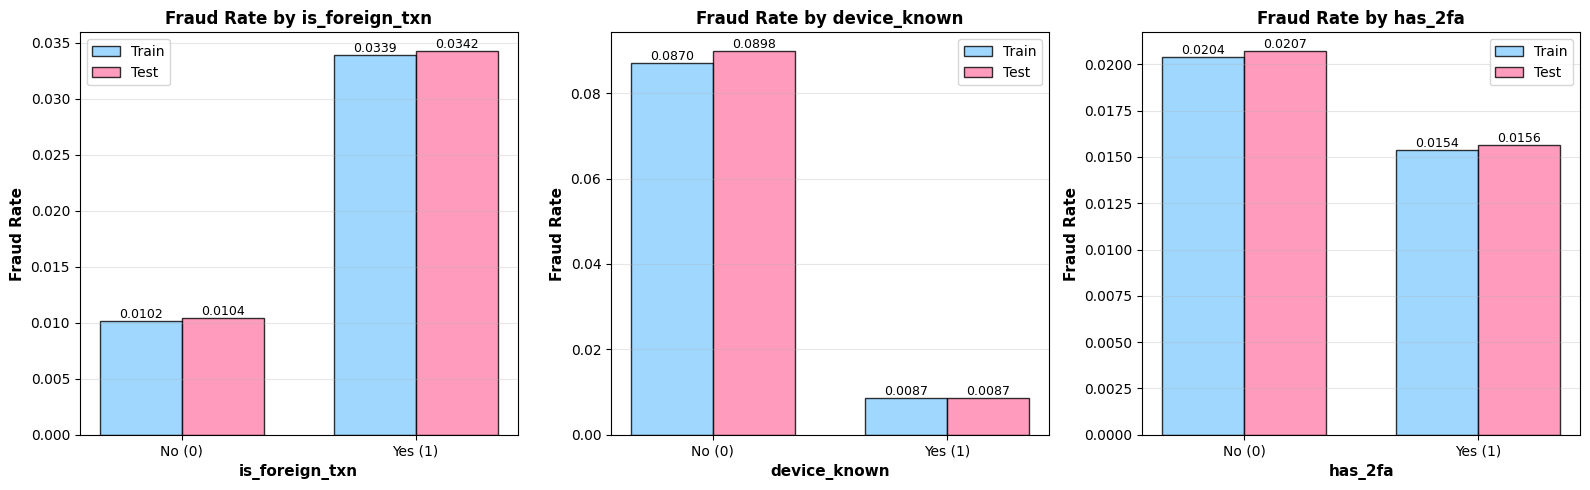


BUSINESS RULE VALIDATION - FRAUD RATE COMPARISON

is_foreign_txn:
  Train: 0=0.0102, 1=0.0339
  Test:  0=0.0104, 1=0.0342

device_known:
  Train: 0=0.0870, 1=0.0087
  Test:  0=0.0898, 1=0.0087

has_2fa:
  Train: 0=0.0204, 1=0.0154
  Test:  0=0.0207, 1=0.0156


In [26]:
# Visualization for Business Rules
business_rules = ['is_foreign_txn', 'device_known', 'has_2fa']
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for idx, rule in enumerate(business_rules):
    # Get fraud rates for train
    train_fraud_by_rule = df.groupby(rule)['is_fraud'].mean()
    test_fraud_by_rule = df_test.groupby(rule)['is_fraud'].mean()
    
    # Prepare data for side-by-side comparison
    x = np.arange(len(train_fraud_by_rule))
    width = 0.35
    
    ax = axes[idx]
    bars1 = ax.bar(x - width/2, train_fraud_by_rule.values, width, label='Train', 
                   color='#87CEFF', edgecolor='black', alpha=0.8)
    bars2 = ax.bar(x + width/2, test_fraud_by_rule.values, width, label='Test', 
                   color='#FF82AB', edgecolor='black', alpha=0.8)
    
    # Labels and title
    ax.set_xlabel(rule, fontsize=11, fontweight='bold')
    ax.set_ylabel('Fraud Rate', fontsize=11, fontweight='bold')
    ax.set_title(f'Fraud Rate by {rule}', fontsize=12, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(['No (0)', 'Yes (1)'])
    ax.legend()
    ax.grid(True, alpha=0.3, axis='y')
    
    # Add value labels on bars
    for bars in [bars1, bars2]:
        for bar in bars:
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height,
                   f'{height:.4f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

# Summary table
print('\n' + '='*70)
print('BUSINESS RULE VALIDATION - FRAUD RATE COMPARISON')
print('='*70)

for rule in business_rules:
    print(f'\n{rule}:')
    train_data = df.groupby(rule)['is_fraud'].agg(['sum', 'count', 'mean']).rename(columns={'mean': 'fraud_rate'})
    test_data = df_test.groupby(rule)['is_fraud'].agg(['sum', 'count', 'mean']).rename(columns={'mean': 'fraud_rate'})
    
    print(f'  Train: 0={train_data.loc[0, "fraud_rate"]:.4f}, 1={train_data.loc[1, "fraud_rate"]:.4f}')
    print(f'  Test:  0={test_data.loc[0, "fraud_rate"]:.4f}, 1={test_data.loc[1, "fraud_rate"]:.4f}')


`is_foreign_txn` and `device_known` seemly **have more impacts** on sepharating fraud transaction than  `has_2fa`. 

The observed proportions **keep consistence** through train and test.